# <font face = 'Impact' color = '#E7625F' > Sample Demonstration on Machine Learning for Regression: Home Price Prediction<font/>
#### <font face = 'Times New Roman' color = '#1F6CB0'> License: GPL v3.0<font/>
#### <font face = 'Times New Roman' color = '#1F6CB0'> Author and Trainer: Paolo Hilado MSc. (Data Science)<font/>
This notebook provides a backgrounder in doing Machine Learning in Python employing Regression Tree model.

# Business Understanding

## 1.1 Business Context
A hypothetical real-estate company, HomeValue Analytics, wants to improve the way it estimates residential property prices. Currently, property prices are estimated using a combination of historical sales, agent experience, location, property size, and other characteristics.  

The company wants to use machine learning to develop a data-driven system that can estimate the expected selling price of a residential property based on its characteristics.  

The proposed machine-learning solution will use historical property information such as:  

Property size  
Number of bedrooms  
Number of bathrooms  
Property age  
Distance from the city center  
Distance from schools  
Distance from shopping centers  
Neighborhood quality  
Parking availability  
Property condition  
The target variable will be the property selling price, making this a supervised regression problem.

## 1.2 Business Problem  
HomeValue Analytics currently relies heavily on manual valuation and simple historical comparisons. This can lead to inconsistent property valuations, particularly when there are many properties with different characteristics.

An inaccurate valuation can result in:
- Properties being overpriced and remaining on the market for too long.
- Properties being underpriced and reducing potential revenue.
- Inconsistent recommendations from different agents.
- Difficulty determining competitive listing prices.
- Increased time required to evaluate properties.
- The business therefore needs a systematic method for estimating property prices.

## 1.3 Business Objective  
The primary business objective is to develop a machine-learning model that can accurately estimate the selling price of residential properties based on their characteristics. The model could eventually be used by property agents as a decision-support tool when preparing property valuations and listing recommendations.


## 1.4 Data Mining Objective
The data-mining objective is to develop a regression model that predicts the continuous variable:  

### selling_price 

using property-related predictor variables.  

The analysis will involve:  

- Loading and exploring the dataset.
- Performing Exploratory Data Analysis
- Data Partitioning
- Data Preprocessing (Feature Scaling and One-hot Coding) and Data Cleaning (when needed)
- Machine Learning Development and Performance Evaluation using RMSE


## 1.5 Business Assumptions  
The hypothetical project makes the following assumptions:  

- Historical property characteristics are reasonably representative of properties that will be evaluated in the future.
- Property size generally has a positive relationship with selling price.
- Properties with more bedrooms and bathrooms generally have higher prices.
- Better neighborhood quality is associated with higher property prices.
- Properties closer to major amenities tend to have higher values.
- Newer properties tend to have higher values than otherwise comparable older properties.
- Property condition influences its selling price.
- The relationship between property characteristics and price is sufficiently strong for regression modeling.
- There are no major changes in the hypothetical property market that would completely invalidate historical relationships.

## 1.6 Success Criteria
Business Success Criteria  
The project will be considered successful if the resulting model:  

Provides reasonably accurate property-price estimates.  
Performs better than a simple baseline prediction, such as predicting the average property price.  
Can support property agents in making consistent valuation decisions.  
Produces predictions that are sufficiently reliable for preliminary property assessment.  

R² ≥ 0.80 on the test dataset.  
RMSE should be reasonably small relative to the typical property price.  
MAE should be sufficiently low that the average prediction error is acceptable to the business.  
The model should not exhibit a large difference between training and testing performance, indicating severe overfitting.  
These thresholds are illustrative and would need to be validated with actual business stakeholders using real property-market data.  

# 2. Data Understanding

## 2.1 Data Owner
The hypothetical data owner is:  

HomeValue Analytics – Property Valuation Department  

The department is assumed to maintain historical information about residential properties and their associated selling prices.  

Because this is a hypothetical project, the organization and dataset do not represent an actual company or proprietary database.  

## 2.2 Data Source
The dataset is hypothetical; it is not collected from real customers, property owners, or real estate transactions.

The variables and their approximate relationships are designed to resemble a residential property-price dataset. The selling price will be generated using a combination of property characteristics and random variation.  

## 2.3 Data Licensing
The dataset is hypothetical and synthetically generated for educational and demonstration purposes.  
License: Creative Commons Attribution 4.0 International (CC BY 4.0), for the purposes of this demonstration.  
No real person's personal information or proprietary business information is included.  
If this project were later converted to use real property data, the licensing terms would need to be reviewed before the data could be distributed or used for modeling.  

## 2.4 Data Format
The dataset is in a CSV format.  
The dataset contains both numerical and categorical variables.  

## 2.5 Dataset Dimensions
For this project, we will generate:  

1,000 observations (rows)  
15 columns  

## 2.6 Data Dictionary

| Variable | Data Type | Description | Role |
|---|---|---|---|
| `property_id` | String | Unique identifier assigned to each property | Identifier |
| `property_size_sqft` | Float | Size of the property in square feet | Predictor |
| `bedrooms` | Integer | Number of bedrooms in the property | Predictor |
| `bathrooms` | Float | Number of bathrooms in the property | Predictor |
| `property_age` | Integer | Age of the property in years | Predictor |
| `distance_city_km` | Float | Distance from the city center in kilometers | Predictor |
| `distance_school_km` | Float | Distance from the nearest school in kilometers | Predictor |
| `distance_shopping_km` | Float | Distance from the nearest shopping center in kilometers | Predictor |
| `neighborhood_quality` | Integer | Neighborhood quality score from 1 to 10 | Predictor |
| `parking_spaces` | Integer | Number of available parking spaces | Predictor |
| `property_condition` | Categorical | Overall condition of the property | Predictor |
| `property_type` | Categorical | Type of residential property | Predictor |
| `has_pool` | Integer | Whether the property has a swimming pool (0 = No, 1 = Yes) | Predictor |
| `has_garden` | Integer | Whether the property has a garden (0 = No, 1 = Yes) | Predictor |
| `selling_price` | Float | Hypothetical selling price of the property | Target |


In [1]:
# Load the data set
import pandas as pd
import numpy as np

df = pd.read_csv("property_price_dataset.csv")
df.head(3)

,property_id,property_size_sqft,bedrooms,bathrooms,property_age,distance_city_km,distance_school_km,distance_shopping_km,neighborhood_quality,parking_spaces,property_condition,property_type,has_pool,has_garden,selling_price
0,PROP_0001,2098.03,2,2.0,17,3.17,7.54,6.09,6,2,Very Good,Apartment,0,1,710276.02
1,PROP_0002,1717.04,2,1.0,1,2.33,0.57,4.41,1,2,Very Good,Townhouse,1,1,661452.17
2,PROP_0003,2188.61,4,1.5,12,14.28,2.95,4.63,4,0,Very Good,Townhouse,1,0,630912.90


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   property_id           1000 non-null   str    
 1   property_size_sqft    1000 non-null   float64
 2   bedrooms              1000 non-null   int64  
 3   bathrooms             1000 non-null   float64
 4   property_age          1000 non-null   int64  
 5   distance_city_km      1000 non-null   float64
 6   distance_school_km    1000 non-null   float64
 7   distance_shopping_km  1000 non-null   float64
 8   neighborhood_quality  1000 non-null   int64  
 9   parking_spaces        1000 non-null   int64  
 10  property_condition    1000 non-null   str    
 11  property_type         1000 non-null   str    
 12  has_pool              1000 non-null   int64  
 13  has_garden            1000 non-null   int64  
 14  selling_price         1000 non-null   float64
dtypes: float64(6), int64(6), str(3)
m


--- Variable: property_size_sqft ---
  Anderson-Darling Statistic : 0.5975
  p-value : 0.1240
  Decision : Fail to Reject Null


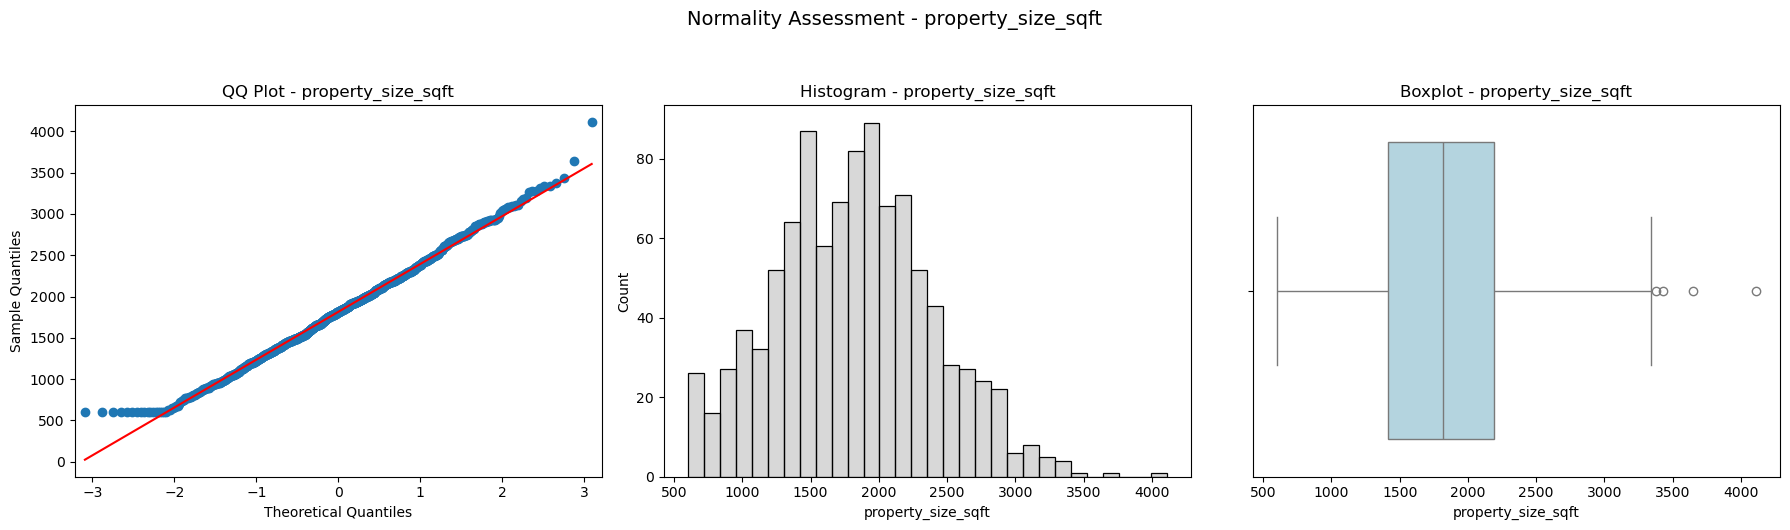


--- Variable: bedrooms ---
  Anderson-Darling Statistic : 31.2662
  p-value : 0.0100
  Decision : Reject Null


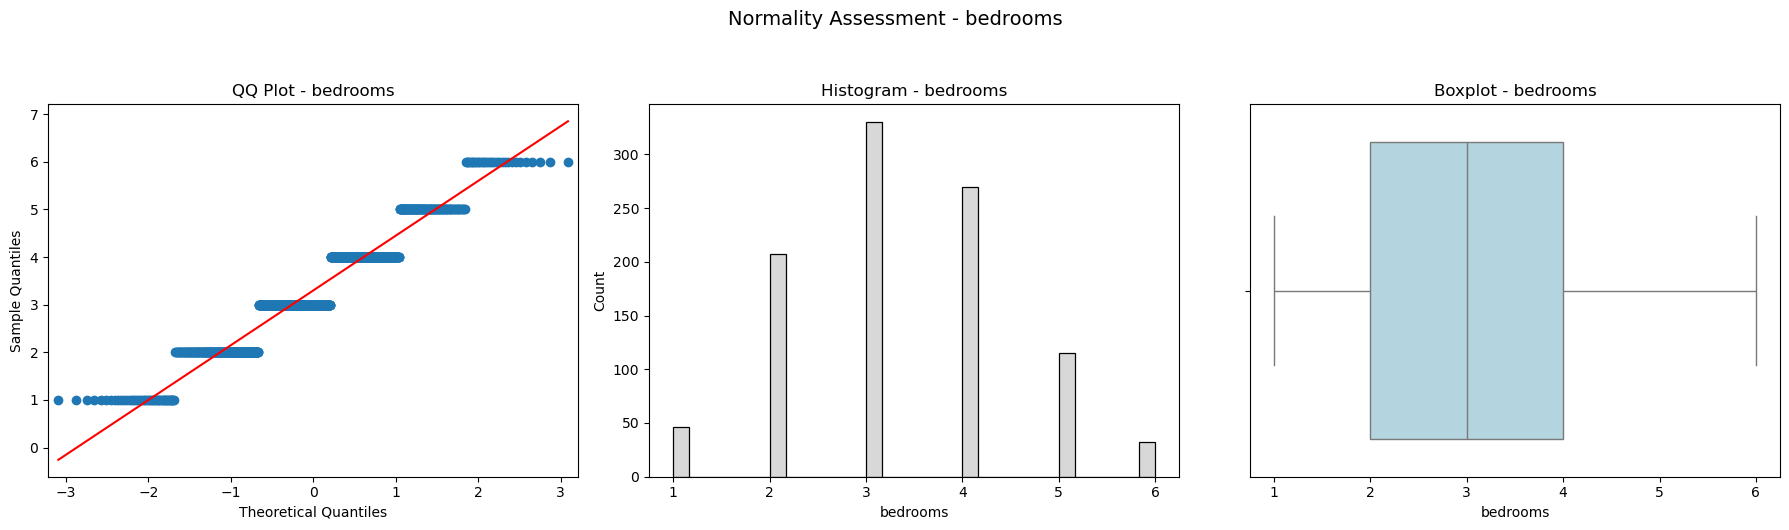


--- Variable: bathrooms ---
  Anderson-Darling Statistic : 26.8759
  p-value : 0.0100
  Decision : Reject Null


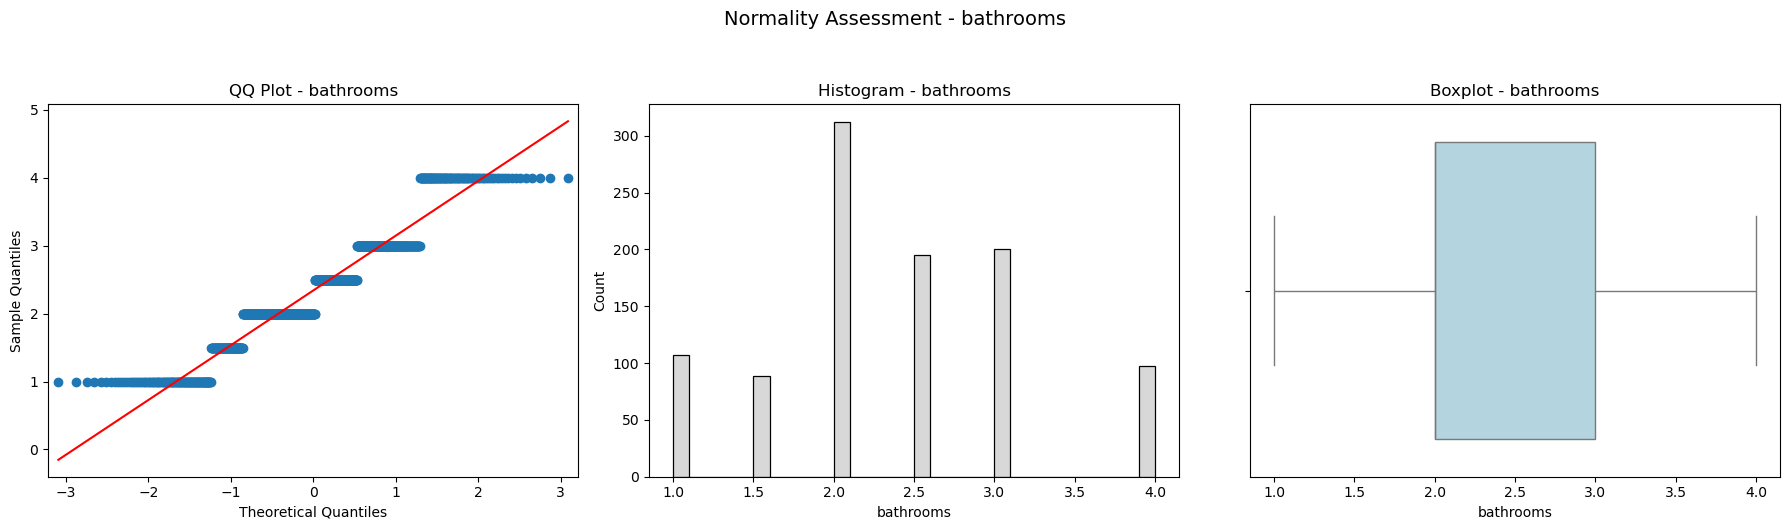


--- Variable: property_age ---
  Anderson-Darling Statistic : 9.6963
  p-value : 0.0100
  Decision : Reject Null


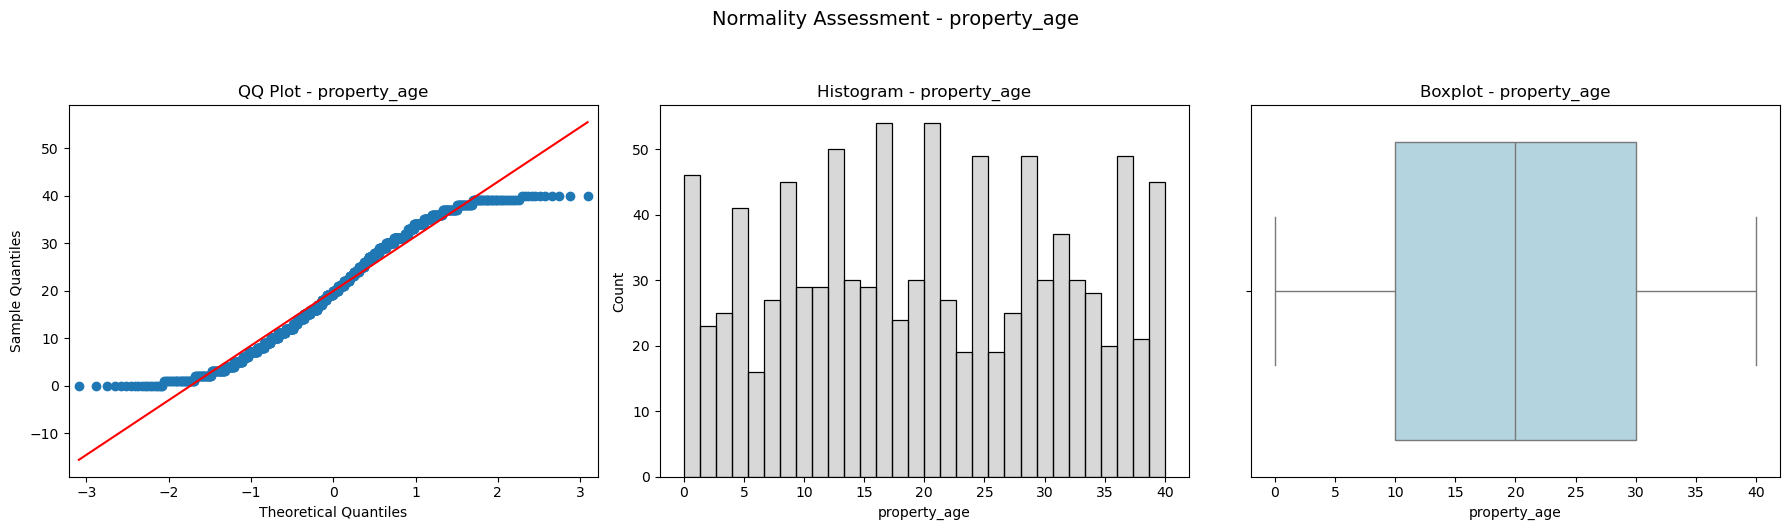


--- Variable: distance_city_km ---
  Anderson-Darling Statistic : 26.8360
  p-value : 0.0100
  Decision : Reject Null


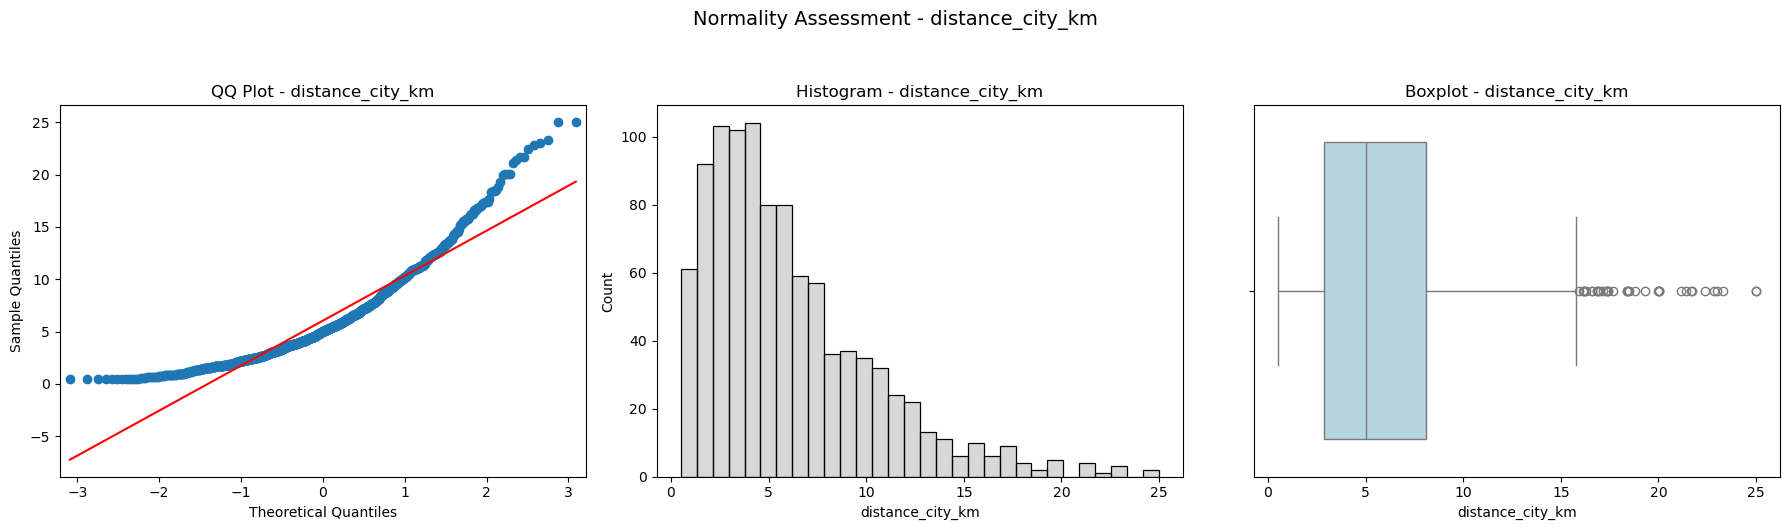


--- Variable: distance_school_km ---
  Anderson-Darling Statistic : 11.9603
  p-value : 0.0100
  Decision : Reject Null


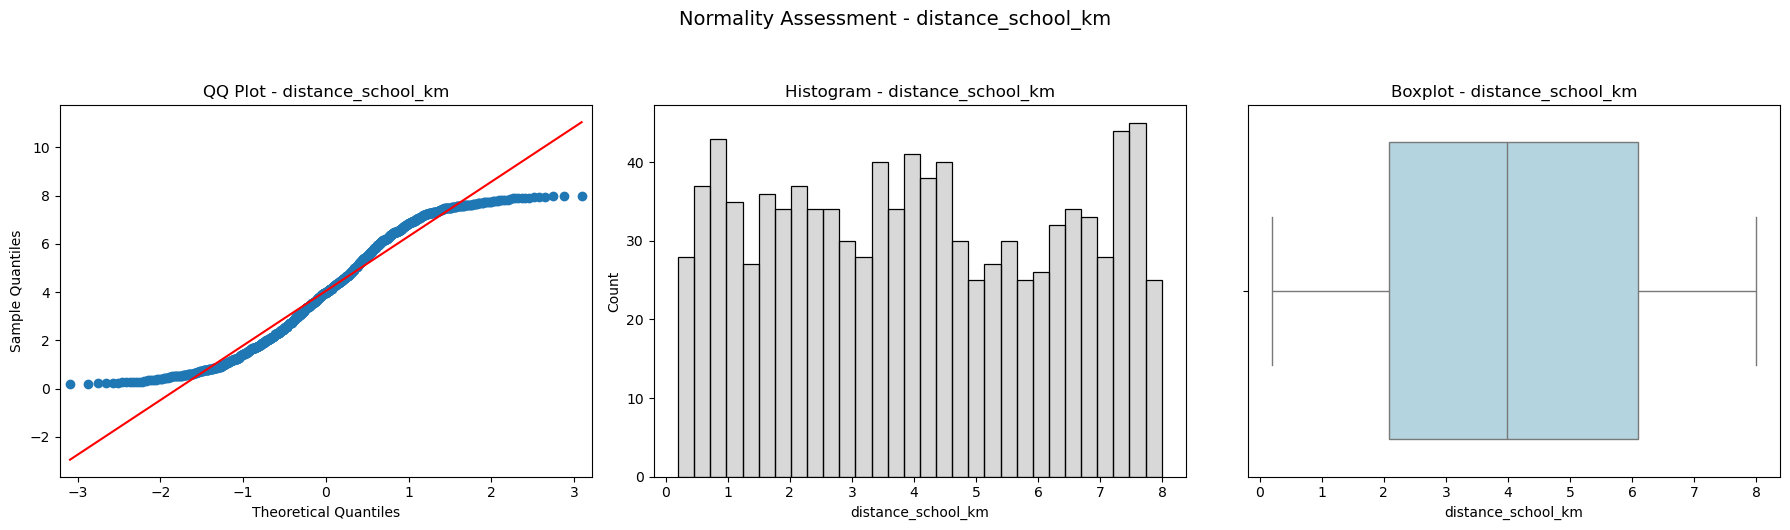


--- Variable: distance_shopping_km ---
  Anderson-Darling Statistic : 9.5584
  p-value : 0.0100
  Decision : Reject Null


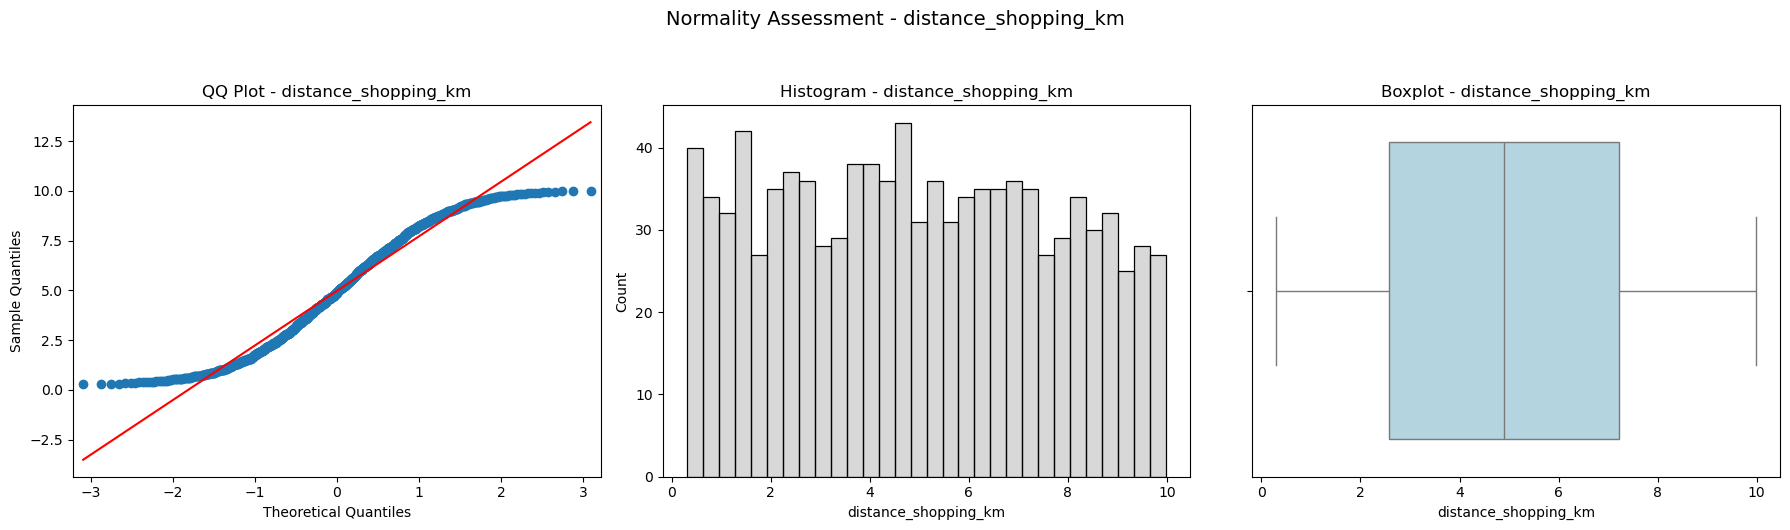


--- Variable: neighborhood_quality ---
  Anderson-Darling Statistic : 15.7714
  p-value : 0.0100
  Decision : Reject Null


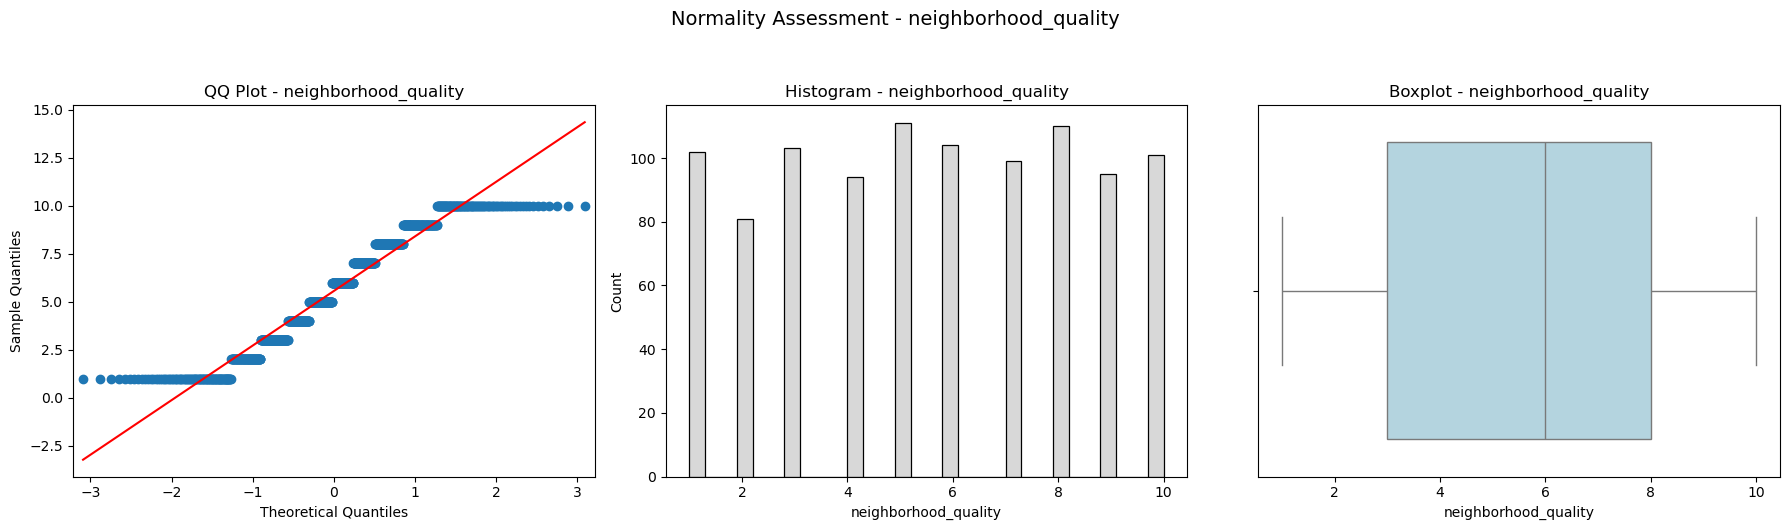


--- Variable: parking_spaces ---
  Anderson-Darling Statistic : 52.1177
  p-value : 0.0100
  Decision : Reject Null


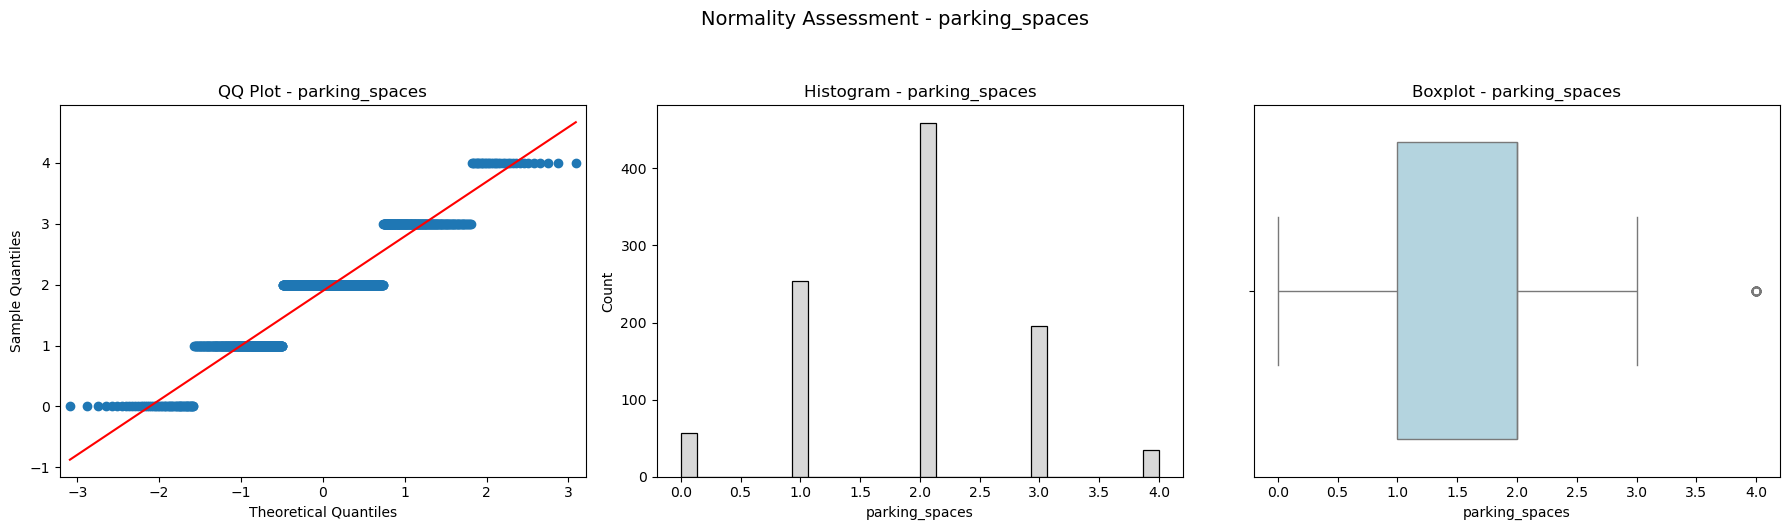


--- Variable: has_pool ---
  Anderson-Darling Statistic : 238.4190
  p-value : 0.0100
  Decision : Reject Null


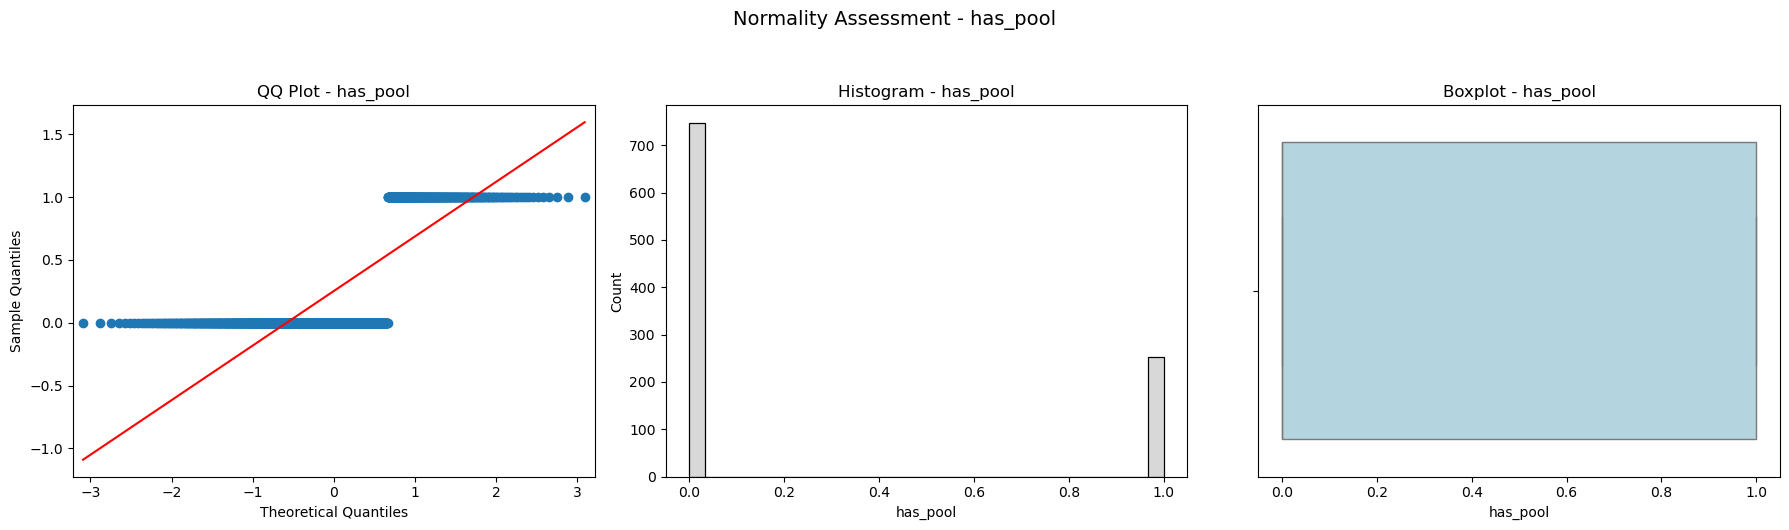


--- Variable: has_garden ---
  Anderson-Darling Statistic : 180.8637
  p-value : 0.0100
  Decision : Reject Null


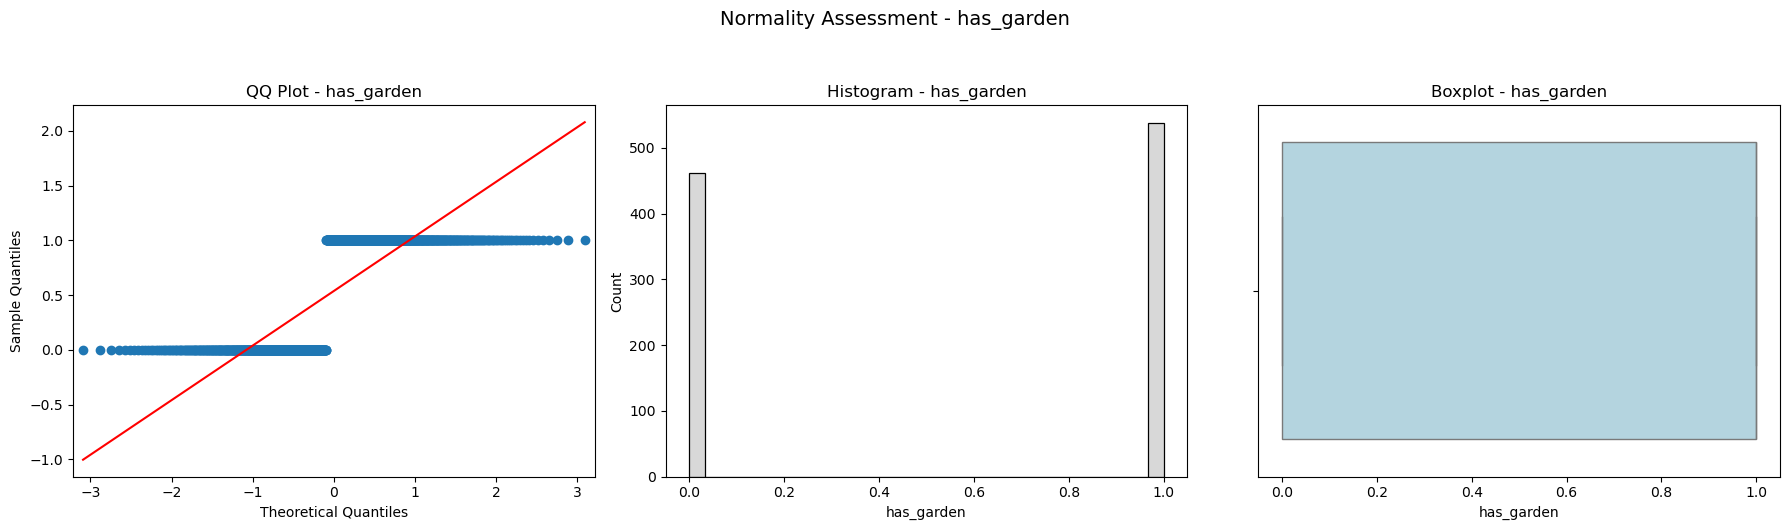


--- Variable: selling_price ---
  Anderson-Darling Statistic : 0.3318
  p-value : 0.1500
  Decision : Fail to Reject Null


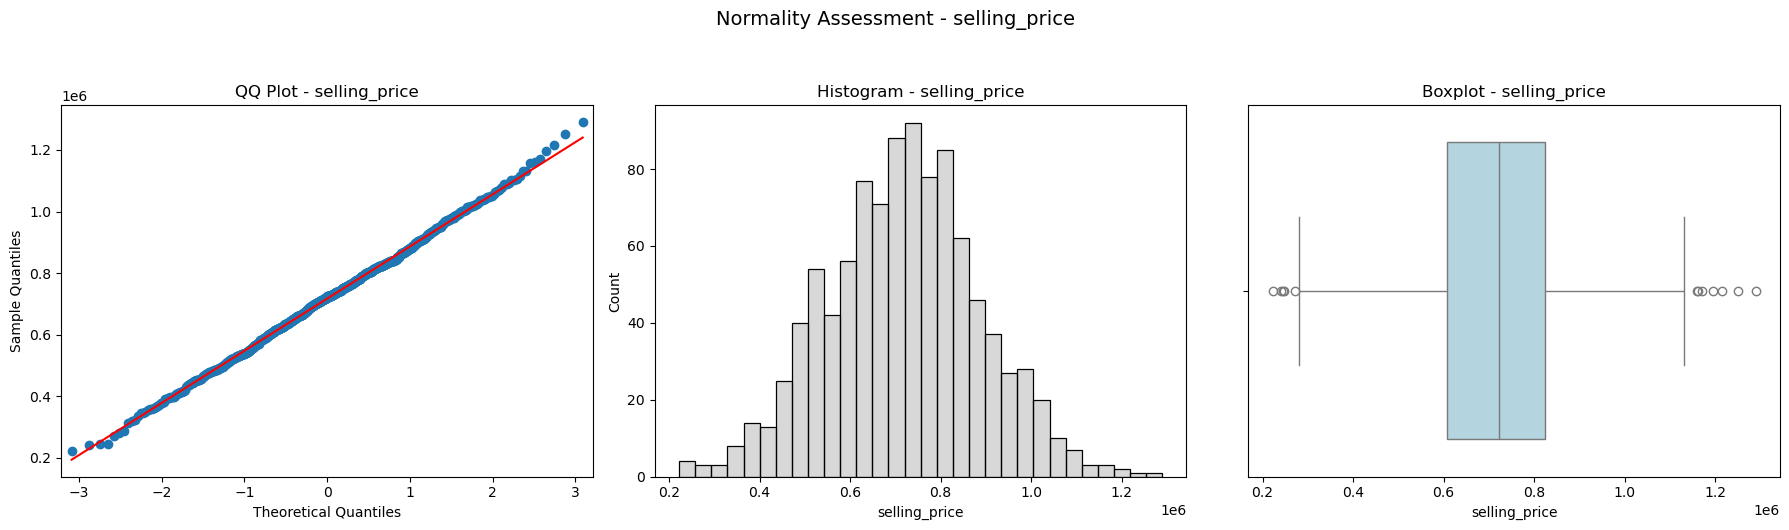

In [2]:
# Perform Exploratory Data Analysis
import qdesc as qd
qd.normcheck_dashboard(df)

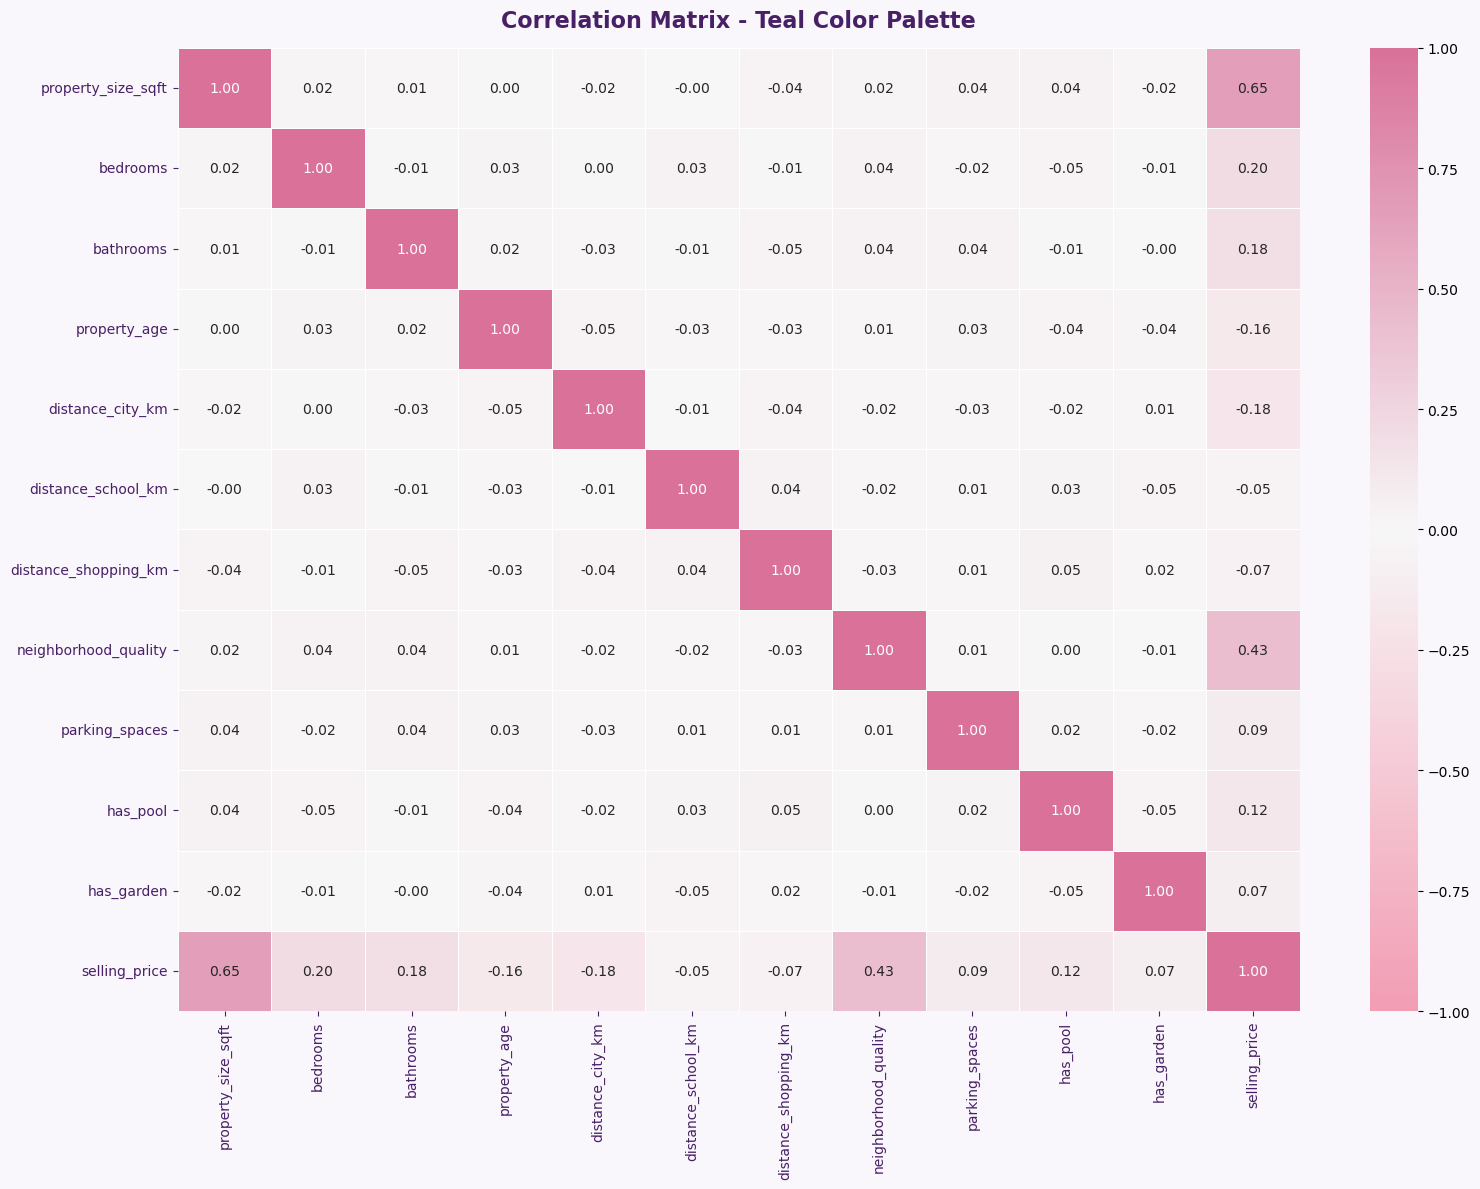

In [3]:
qd.corr_heatmap(df, method="spearman", palette="rose", title="Correlation Matrix - Teal Color Palette")

In [4]:
qd.vif(df, exclude= "selling_price")

,Feature,VIF
0,has_pool,1.014585
1,distance_shopping_km,1.012527
2,distance_city_km,1.011214
3,property_age,1.010284
4,parking_spaces,1.009445
5,distance_school_km,1.008688
6,has_garden,1.007856
7,bedrooms,1.007783
8,property_size_sqft,1.007057
9,bathrooms,1.006482


In [3]:
# Separate explanatory variables (X) and target variable (y)

X = df.drop(columns=["property_id", "selling_price"])
y = df["selling_price"]

print("X dimensions:", X.shape)
print("y dimensions:", y.shape)

X dimensions: (1000, 13)
y dimensions: (1000,)


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (800, 13)
Testing set: (200, 13)


# Regression Tree - Machine Learning  Training and Testing

In [7]:
# Train a model for Regression Tree
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import r2_score
import warnings

warnings.filterwarnings("ignore")

numeric_features = X_train.select_dtypes(
    include=["number"]
).columns

categorical_features = X_train.select_dtypes(
    include=["object", "string", "str", "category"]
).columns

preprocessor = ColumnTransformer([
    ("num", "passthrough", numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

# Defining the pipeline for  Regression.
pipeline = Pipeline([
    ("preprocessor", preprocessor),           
    ('regtree', DecisionTreeRegressor())            
    ]
)

# Define hyperparameters to tune
param_grid = {
    "regtree__max_depth": [3, 5, 7, 10, 15, None],

    "regtree__min_samples_split": [2, 5, 10, 20],

    "regtree__min_samples_leaf": [1, 2, 5, 10],

    "regtree__max_features": [None, "sqrt", "log2"]
}

# Define setup for cross-validation
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Perform cross-validation grid search
regtree_grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=cv, scoring='neg_root_mean_squared_error' )
regtree_grid_search.fit(X_train, y_train)

# Get the best hyperparameters
best_params = regtree_grid_search.best_params_
print("Best hyperparameters:", best_params)

# Get the best model
best_model = regtree_grid_search.best_estimator_
# CV RMSE of best model
cv_rmse = -regtree_grid_search.best_score_  # negate because sklearn uses "maximize" convention
print("Mean 5-fold CV RMSE:", np.round(cv_rmse,2))

# Evaluate the best model on the train set using RMSE
y_train_pred = best_model.predict(X_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))  # RMSE on train set
print("Root Mean Squared Error on train set:", np.round(rmse_train,2))

# Calculate train R²
train_r2 = r2_score(y_train, y_train_pred)
print("Train R²:", train_r2)

Best hyperparameters: {'regtree__max_depth': 7, 'regtree__max_features': None, 'regtree__min_samples_leaf': 5, 'regtree__min_samples_split': 20}
Mean 5-fold CV RMSE: 107228.71
Root Mean Squared Error on train set: 74824.51
Train R²: 0.8027898944735402


In [41]:
# Evaluate the best Regression Tree model on the test set using RMSE
y_test_pred = best_model.predict(X_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))  # RMSE on test set
print("Root Mean Squared Error on test set:", np.round(rmse_test,2))

# Calculate test R²
test_r2 = r2_score(y_test, y_test_pred)
print("Test R²:", test_r2)

Root Mean Squared Error on test set: 102363.11
Test R²: 0.6456908550151622


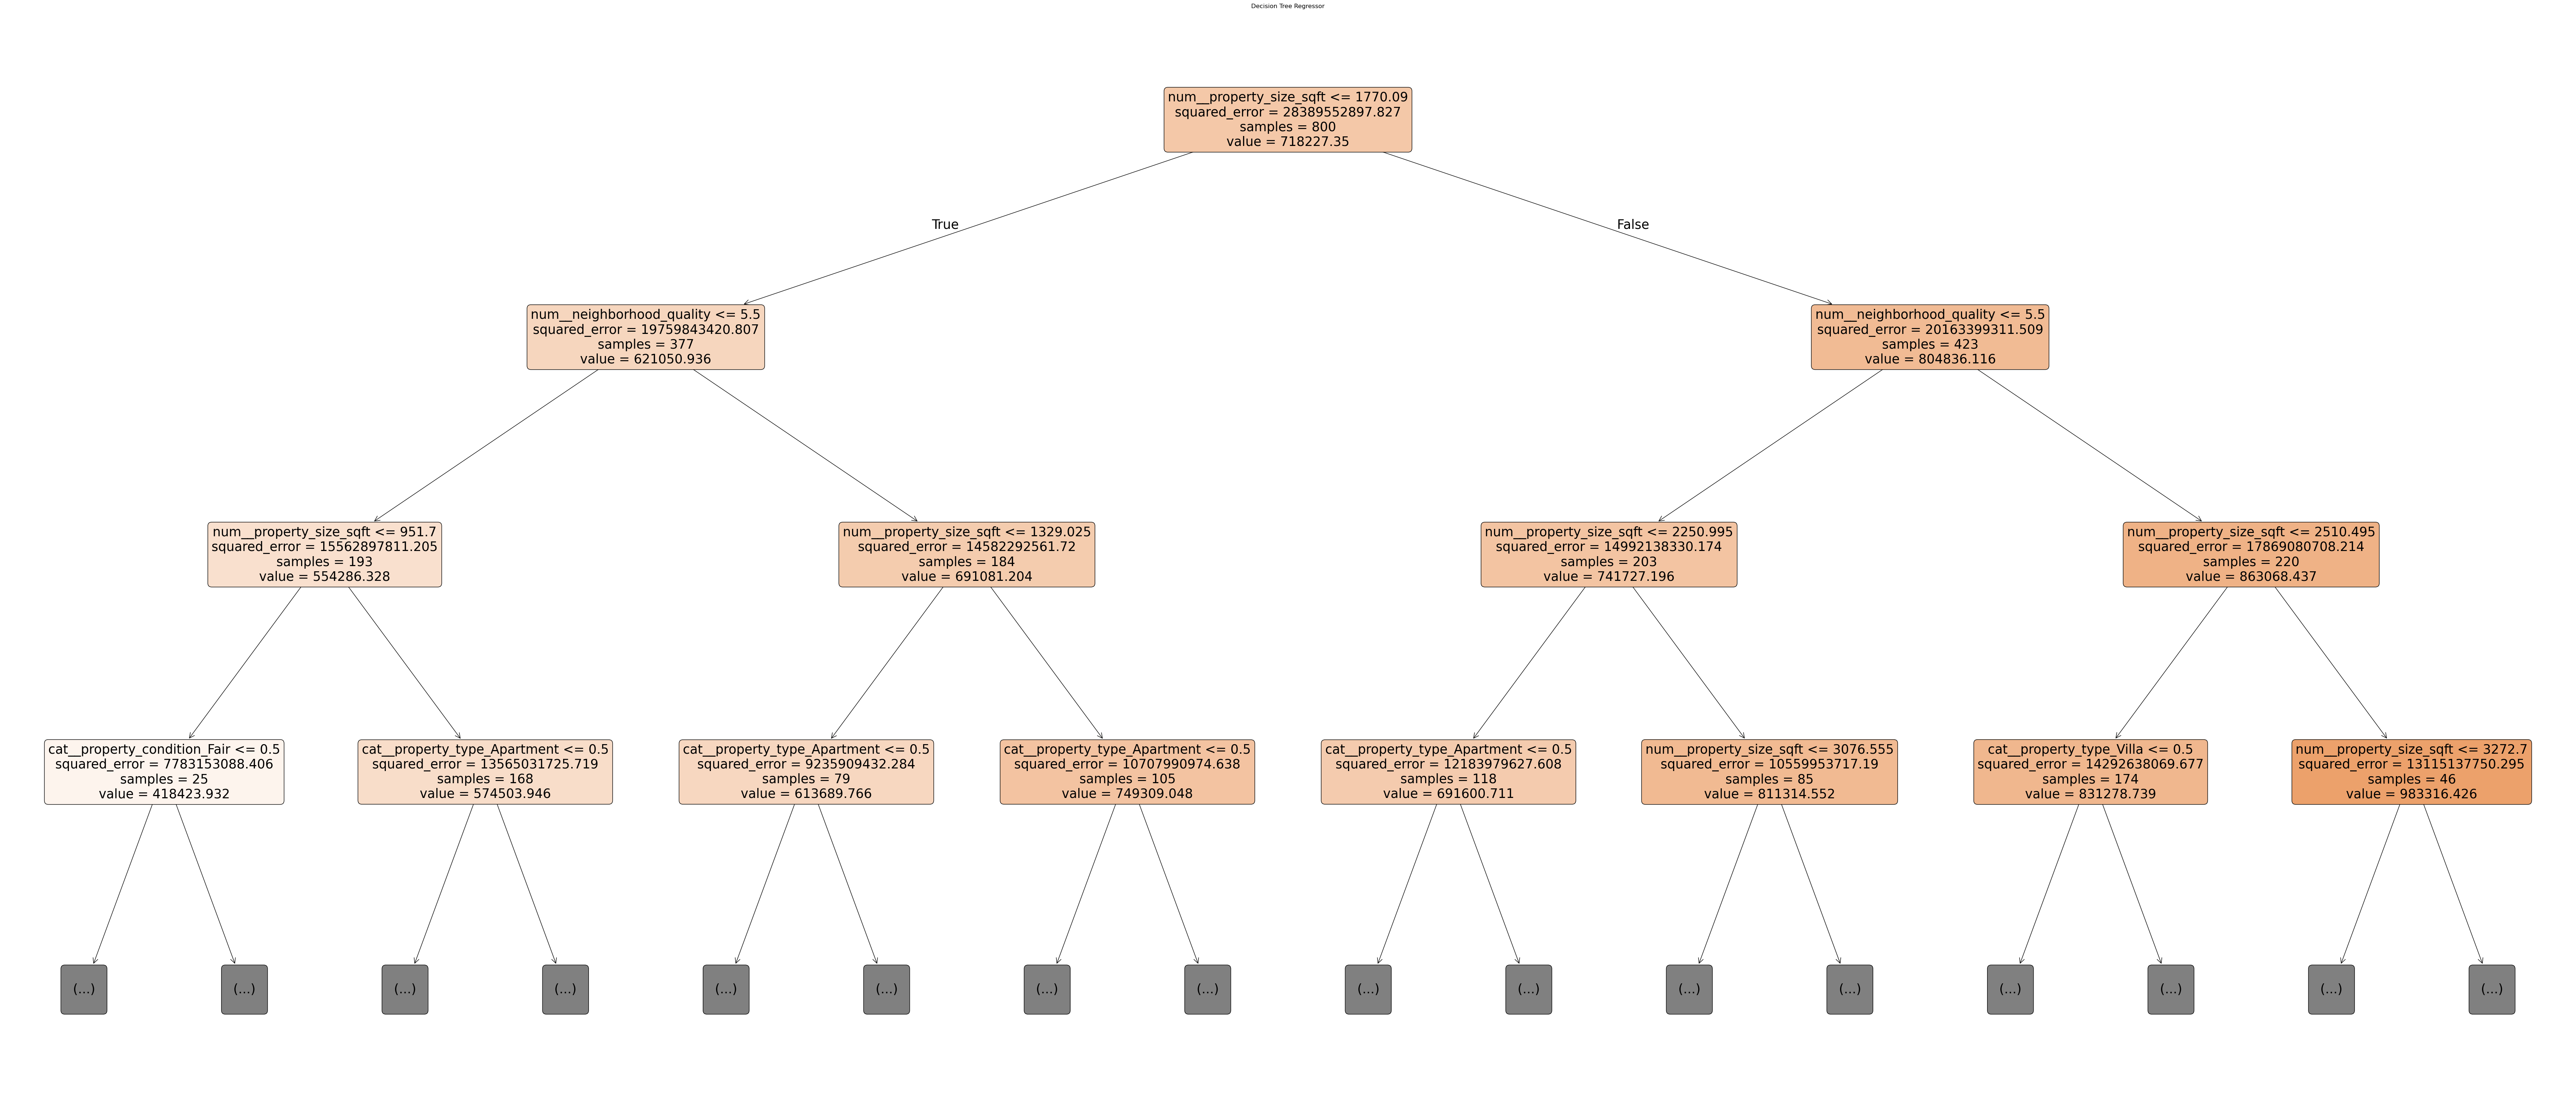

In [7]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Get the trained DecisionTreeRegressor from the pipeline
tree_model = best_model.named_steps["regtree"]

# Get the preprocessor
preprocessor = best_model.named_steps["preprocessor"]

# Get the feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Create the visualization
plt.figure(figsize=(70, 30))

plot_tree(
    tree_model,
    feature_names=feature_names,
    filled=True,
    rounded=True,
    max_depth = 3,
    fontsize=25
)

plt.title("Decision Tree Regressor")
plt.tight_layout()
plt.show()

# Random Forest - Machine Learning  Training and Testing

In [5]:
# Train a Random Forest Regressor
import numpy as np
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import warnings

warnings.filterwarnings("ignore")

# Identify numeric and categorical features
numeric_features = X_train.select_dtypes(
    include=["number"]
).columns

categorical_features = X_train.select_dtypes(
    include=["object", "string", "str", "category"]
).columns

# Preprocessing
preprocessor = ColumnTransformer([
    ("num", "passthrough", numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

# Define the Random Forest pipeline
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("rf", RandomForestRegressor())
])

# Define hyperparameters to tune
param_grid = {
    "rf__n_estimators": [100, 200, 300],
    
    "rf__max_depth": [None, 5, 10, 15, 20],
    
    "rf__min_samples_split": [2, 5, 10],
    
    "rf__min_samples_leaf": [1, 2, 5],
    
    "rf__max_features": [1.0, "sqrt", "log2"]
}

# Define setup for cross-validation
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Perform cross-validation grid search
rf_grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

rf_grid_search.fit(X_train, y_train)

# Get the best hyperparameters
best_params = rf_grid_search.best_params_
print("Best hyperparameters:", best_params)

# Get the best model
best_model = rf_grid_search.best_estimator_

# CV RMSE of best model
cv_rmse = -rf_grid_search.best_score_
print("Mean 5-fold CV RMSE:", np.round(cv_rmse, 2))

# Evaluate the best model on the training set
y_train_pred = best_model.predict(X_train)

# Train RMSE
rmse_train = np.sqrt(
    mean_squared_error(y_train, y_train_pred)
)

print(
    "Root Mean Squared Error on train set:",
    np.round(rmse_train, 2)
)

# Train R²
train_r2 = r2_score(y_train, y_train_pred)

print("Train R²:",np.round(train_r2, 3))

Best hyperparameters: {'rf__max_depth': 15, 'rf__max_features': 1.0, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 2, 'rf__n_estimators': 200}
Mean 5-fold CV RMSE: 80437.51
Root Mean Squared Error on train set: 29846.69
Train R²: 0.969


In [6]:
# Evaluate the best Random Forest Model on the test set using RMSE
y_test_pred = best_model.predict(X_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))  # RMSE on test set
print("Root Mean Squared Error on test set:", np.round(rmse_test,2))

# Calculate test R²
test_r2 = r2_score(y_test, y_test_pred)
print("Test R²:", test_r2)

Root Mean Squared Error on test set: 81063.72
Test R²: 0.7777977342219153


In [8]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score

models = {
    "regtree": regtree_grid_search,
    "rf": rf_grid_search
}

results = []

for name, grid in models.items():

    # Best model
    best_model = grid.best_estimator_

    # Predictions
    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)

    # CV RMSE
    cv_rmse = -grid.best_score_

    # Train metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    train_r2 = r2_score(y_train, y_train_pred)

    # Test metrics
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_r2 = r2_score(y_test, y_test_pred)

    results.append({
        "Model": name,
        "CV RMSE": cv_rmse,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "Train R²": train_r2,
        "Test R²": test_r2
    })

results_df = pd.DataFrame(results)

# Round the values
results_df.iloc[:, 1:] = results_df.iloc[:, 1:].round(5)

display(results_df)

,Model,CV RMSE,Train RMSE,Test RMSE,Train R²,Test R²
0,regtree,107228.70937,74824.50616,102363.11080,0.80279,0.64569
1,rf,80437.50927,29846.68544,81063.72123,0.96862,0.77780
